In [1]:
# Imports for data access, COSI unbinned response/background modeling, threeML fitting, and timing analysis.
from pathlib import Path
from cosipy.util import fetch_wasabi_file
from cosipy.spacecraftfile import SpacecraftHistory
from astropy.time import Time

import astropy.units as u
from copy import deepcopy
import matplotlib.pyplot as plt
import numpy as np

from threeML import PointSource, Model, JointLikelihood, DataList
from astromodels import Parameter, Powerlaw

from cosipy.threeml.unbinned_model_folding import CachedUnbinnedThreeMLModelFolding
from cosipy.statistics import UnbinnedLikelihood
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.interfaces.expectation_interface import SumExpectationDensity

from cosipy.event_selection.time_selection import TimeSelector
from cosipy.data_io.EmCDSUnbinnedData import TimeTagEmCDSEventDataInSCFrameFromDC3Fits

from cosipy.response.ml.NFResponse import NFResponse
from cosipy.response.ml.nf_instrument_response_function import UnpolarizedNFFarFieldInstrumentResponseFunction

from cosipy.background_estimation.ml.NFBackground import NFBackground
from cosipy.background_estimation.ml.nf_unbinned_background import FreeNormNFUnbinnedBackground

from cosipy.threeml.ml.optimized_unbinned_folding import UnbinnedThreeMLPointSourceResponseIRFAdaptive

/Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


18:33:58 INFO      Starting 3ML!                                                                     ]8;id=5888955;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5888956;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=5888962;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5888963;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=5888969;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5888970;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#46\46]8;;\

         WARNING    to disable these messages, turn off start_warning in your config file            ]8;id=5888976;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5888977;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#47\47]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=5889005;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5889006;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

18:33:59 WARNING   No fermitools installed                                              ]8;id=5889013;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=5889014;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=5889020;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5889021;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=5889026;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5889027;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=5889032;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5889033;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

# Data

### Cached response file

This tutorial uses a pre-computed source response cache to avoid regenerating the response, which is computationally expensive and time-consuming.

The cached response file is larger than GitHub's 100 MB file-size limit, so it is not included in this repository. Please download `Crab_source_response_cache.h5` separately from:

https://drive.google.com/file/d/1EV5wGASx0rmcJIhYSQlOjJNDXHjSDpuU/view?usp=drive_link

After downloading, place it in:

`docs/tutorials/phase_resolved_analysis/cached_response_crab_for_timing/`

The expected full path is:

`docs/tutorials/phase_resolved_analysis/cached_response_crab_for_timing/Crab_source_response_cache.h5`

In [2]:
# Download the Crab event data, spacecraft orientation history, background events, and ML model files used below.
data_path = Path(".") # Current path by default

crab_data_path = data_path / "Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Sources/Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz', output=str('Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz'), 
                checksum = '74ae81a979caf3e398b20091779851bb')

sc_orientation_path = data_path / "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits',
                  checksum = 'ca94ff1d7a73c1f41479aaf598807673', output=str(sc_orientation_path))

bkg_data_path = data_path / "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz',
                  checksum = '73c8b23e43684da3b35c25499254202b', output=str(bkg_data_path))

rsp_path = data_path / "unpolarized_nfresponse_v1-01.pt"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/unpolarized_nfresponse_v1-01.pt',
                  checksum = 'bf2d0c16eac5954fb56489480c2602ca', output=str(rsp_path))

bkg_path = data_path / "nfbackground_v1-01.pt"
fetch_wasabi_file('COSI-SMEX/DC4/Data/Responses/nfbackground_v1-01.pt',
                  checksum = '52a4fb024930e18430bff80db882d3d5', output=str(bkg_path))

A file named Crab_DC4_3months_unbinned_data_filtered_with_SAAcut.fits.gz already exists with the specified checksum (74ae81a979caf3e398b20091779851bb). Skipping.
A file named DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits already exists with the specified checksum (ca94ff1d7a73c1f41479aaf598807673). Skipping.
A file named Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz already exists with the specified checksum (73c8b23e43684da3b35c25499254202b). Skipping.
A file named unpolarized_nfresponse_v1-01.pt already exists with the specified checksum (bf2d0c16eac5954fb56489480c2602ca). Skipping.
A file named nfbackground_v1-01.pt already exists with the specified checksum (52a4fb024930e18430bff80db882d3d5). Skipping.


# Define data files and a small time interval

In [3]:
# Restrict the full simulation to a one-day interval and load source + background events for that interval.
tstart = Time("2028-03-23 10:36:00.000")
tstop = Time("2028-03-24 10:36:00.000")
sc_orientation = SpacecraftHistory.open(sc_orientation_path)
sc_orientation = sc_orientation.select_interval(tstart, tstop)


data_file = [crab_data_path, bkg_data_path]
selector = TimeSelector(tstart = sc_orientation.tstart, tstop = sc_orientation.tstop)
data = TimeTagEmCDSEventDataInSCFrameFromDC3Fits(data_file, selection=selector)

In [4]:
print(f"This analysis uses {data.nevents} events")
print(f"This analysis uses delta_T of {(tstop.mjd-tstart.mjd)*24} hours")

This analysis uses 1871503 events
This analysis uses delta_T of 24.0 hours


# Initializing neutral network machinery

In [5]:
# PyTorch calls the Apple GPU backend "mps" (Metal Performance Shaders).
# The COSI response-generator code required small MPS-compatibility changes:
# in particular, tensors/arrays sent to MPS must use float32 rather than float64,
# because PyTorch's MPS backend does not support float64 tensors.
# If MPS is not available/configured on your computer, switch back to the CPU line below.

# Optional on Apple Silicon when MPS support is available:
devices = ["mps"]
# Otherwise
#devices = ["cpu"]

# Use the former to start with

In [6]:
# Load the neural-network instrument response on the selected compute device.
rsp = NFResponse(
    path_to_model=rsp_path,
    area_batch_size=300_000,
    density_batch_size=100_000,
    devices=devices,
    area_compile_mode=None,
    density_compile_mode=None,
    show_progress=True)

irf = UnpolarizedNFFarFieldInstrumentResponseFunction(rsp)

In [7]:
# Load the neural-network background model using the same compute device.
bkg_model = NFBackground(
    path_to_model=bkg_path,
    density_batch_size=100_000,
    devices=devices,
    density_compile_mode=None,
    show_progress=True)

bkg = FreeNormNFUnbinnedBackground(
    model=bkg_model,
    data=data,
    sc_history=sc_orientation,
    label="bkg_norm")

In [8]:
# Build the event-by-event point-source response object and use batching to control memory use.
psr = UnbinnedThreeMLPointSourceResponseIRFAdaptive(
    data=data,
    irf=irf,
    sc_history=sc_orientation,
    show_progress=True,
    force_energy_node_caching=True,
    reduce_memory=True)

psr.cache_batch_size = 100_000
psr.integration_batch_size = 100_000

In [9]:
# Define the Crab position and an initial power-law spectrum for the source model.
l = 184.56
b = -5.78

index = -2.00
piv = 1. * u.keV
K = 4.94717171 / u.cm / u.cm / u.s / u.keV

spectrum = Powerlaw(index=index, K=K.value, piv=piv.value)

spectrum.index.min_value = -4
spectrum.index.max_value = -1

spectrum.K.unit = K.unit
spectrum.piv.unit = piv.unit

spectrum.index.delta = 0.01
spectrum.K.delta = 0.1

In [10]:
spectrum_inj = deepcopy(spectrum)

In [11]:
# Combine the Crab position and spectrum into the threeML source model.
source = PointSource("Crab",
                     l=l,
                     b=b,
                     spectral_shape=spectrum)
model = Model(source)

### Let's time the NN response

In [12]:
# Out of curiosity; no need to run
#import time
#import torch

#torch.mps.synchronize()
#t_start = time.perf_counter()

In [13]:
# Wrap the point-source response in the cached model-folding interface used by the likelihood.
response = CachedUnbinnedThreeMLModelFolding(psr)

In [14]:
# The total event expectation density is the sum of the source and background contributions.
expectation_density = SumExpectationDensity(response, bkg)

In [15]:
# Construct the unbinned likelihood and expose it to threeML through the COSI plugin.
like_fun = UnbinnedLikelihood(expectation_density)
cosi = ThreeMLPluginInterface('cosi', like_fun, response, bkg)

In [16]:
# Use the background model's average rate as the starting value for a free background normalization.
bkg_norm = bkg.norm.to_value(u.Hz)

cosi.bkg_parameter['bkg_norm'] = Parameter("bkg_norm",
                                          bkg_norm,
                                          unit = u.Hz,
                                          min_value=0,
                                          max_value=150,
                                          delta=0.05,
                                          )

print(f"The average background flux is {bkg_norm:.2f} Hz")

The average background flux is 25.64 Hz


In [17]:
# Assemble the source model and COSI likelihood into a standard threeML JointLikelihood.
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False) # You can enable debugging

18:40:40 INFO      set the minimizer to minuit                                             ]8;id=5889040;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=5889041;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\

## Initializing the Cache

In [18]:
# This tutorial loads a response cache that has already been generated, which avoids the long response calculation.
# This should already be in your directory - but if you do not already have it, comment out the load_caches line below and instead run the
# response-evaluation cell immediately below (currently commented out) to generate the cache, then save it for reuse.
response.load_caches(data_path / "cached_response_crab_for_timing")

In [19]:
# Uncomment this when generating the response/cache from scratch.
# Evaluating the expected counts forces the cached response quantities needed by the likelihood to be computed.
#print(f"Data Events: {data.nevents}\nExpected Events: {expectation_density.expected_counts():.2f}\nRelative Deviation {100 * (expectation_density.expected_counts()/data.nevents - 1):.3f} %")

In [20]:
# Again, out of curiosity, timed the NN response generator
#torch.mps.synchronize()
#t_end = time.perf_counter()

#print(f"Elapsed time: {t_end - t_start:.1f} s")
#Elapsed time: 8296.9 s (on my Macbook Pro M1, using MPS device, the response generator took approximately 2.3 hours 
# for 1 day of Crab+full background and approximately 1.8M events)

## Save the cache for later iterations

In [21]:
# After generating a cache from scratch, uncomment this line to save it for future runs.
#response.save_caches(data_path / "cached_response_crab_for_timing")

# Event-by-event source and background expectation densities

### Perform the unbinned likelihood fit to establish best-fit parameters of your Crab model and rate of the background

In [22]:
# Fit the source and background model parameters before computing the event weights.
like.fit()

/Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
18:40:50 INFO      Starting 3ML!                                  ]8;id=5827847;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5827848;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\
         WARNING   WARNINGs here are NOT errors                   ]8;id=5827854;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=5827855;file:///Users/gyounes/miniforge3/envs/cosipy_env/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\
         WARNING   but are inform you about optional packages     ]8;id=58

Evaluating the density:   0%|          | 0/1871503 [00:00<?, ?calls/s]

Best fit values:

,result,unit
parameter,,
Crab.spectrum.main.Powerlaw.K,(1.83 -0.34 +0.4) x 10,1 / (keV s cm2)
Crab.spectrum.main.Powerlaw.index,-2.257 +/- 0.035,
bkg_norm,(2.5558 +/- 0.0020) x 10,Hz


Correlation matrix:

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,1.476502e+07
total,1.476502e+07


Values of statistical measures:

,statistical measures
AIC,2.953005e+07
BIC,2.953008e+07


(                                       value  negative_error  positive_error  \
 Crab.spectrum.main.Powerlaw.K      18.334579       -3.232753        3.974454   
 Crab.spectrum.main.Powerlaw.index  -2.257323       -0.034124        0.033275   
 bkg_norm                           25.558410       -0.020543        0.019259   
 
                                       error             unit  
 Crab.spectrum.main.Powerlaw.K      3.603603  1 / (keV s cm2)  
 Crab.spectrum.main.Powerlaw.index  0.033699                   
 bkg_norm                           0.019901               Hz  ,
        -log(likelihood)
 cosi       1.476502e+07
 total      1.476502e+07)

In [23]:
# Compute S/(S+B) weights using the fitted model 

# Evaluate event-by-event densities after the fit
S_fit = np.asarray(response.expectation_density(), dtype=np.float64) # Pulsar
B_fit = np.asarray(bkg.expectation_density(), dtype=np.float64) # Background

weights = np.divide(
    S_fit,
    S_fit + B_fit,
    out=np.zeros_like(S_fit),
    where=(S_fit + B_fit) > 0
)

N_src_fit = response.expected_counts()
N_bkg_fit = bkg.expected_counts()

print(f"Observed events             : {data.nevents}")
print(f"Expected source counts      : {N_src_fit}")
print(f"Expected background counts  : {N_bkg_fit}")
print(f"Expected total              : {N_src_fit + N_bkg_fit}")

print()
print(f"sum(w_fit)                  : {weights.sum()}")
print(f"sum(1-w_fit)                : {(1 - weights).sum()}")

print()
print(f"Mean fitted weight          : {weights.mean()}")
print(f"Model source fraction       : {N_src_fit/(N_src_fit + N_bkg_fit)}")

Observed events             : 1871503
Expected source counts      : 46611.62032447975
Expected background counts  : 1824870.4936970773
Expected total              : 1871482.114021557

sum(w_fit)                  : 46614.92623679462
sum(1-w_fit)                : 1824888.0737632054

Mean fitted weight          : 0.024907748604621322
Model source fraction       : 0.024906260110772745


## Table of info with timing-relevant information

In [24]:
# Collect the event times, energies, fitted expectation densities, and weights in one timing table.
from astropy.table import Table

timing = Table()

timing["event_index"] = np.arange(data.nevents)

timing["time_jd1"] = data.time.jd1
timing["time_jd2"] = data.time.jd2
timing["time_mjd"] = data.time.mjd

timing["energy_keV"] = np.asarray(data.energy_keV)

timing["source_density"] = S_fit
timing["background_density"] = B_fit
timing["weight"] = weights

timing.meta["TIME_SCALE"] = data.time.scale

In [25]:
print(timing)

event_index  time_jd1 ...   background_density           weight        
----------- --------- ... ---------------------- ----------------------
          0 2461854.0 ...   0.002344507120749331  4.265288813684045e-10
          1 2461854.0 ...  0.0006073706865671831 1.6464409963633404e-09
          2 2461854.0 ...  0.0005068607630481196 1.9729284074256405e-09
          3 2461854.0 ...  0.0012882785102670193  7.762296671520989e-10
          4 2461854.0 ...  0.0009997213023730963 1.0002787743203665e-09
          5 2461854.0 ... 0.00011301199779319916  8.848617940382611e-09
          6 2461854.0 ...  0.0006772526996901546 1.4765537279968758e-09
          7 2461854.0 ... 3.9217606451266986e-05  2.549875081601117e-08
          8 2461854.0 ...   0.002991991496824067 3.3422554867794656e-10
          9 2461854.0 ...  7.704369166597563e-05 1.2979647851713426e-08
        ...       ... ...                    ...                    ...
    1871493 2461855.0 ...  0.0001927848774487787  5.187128824866

# H-test utilities

In [26]:
# Implement the ordinary or probability-weighted H-test, allowing up to mmax harmonics.
import numpy as np

def h_test(phases, weights=None, mmax=20):
    """
    H-test / weighted H-test.

    Parameters
    ----------
    phases : array
        Pulse phases in [0, 1).
    weights : array or None
        Photon probability weights.
        None -> ordinary/unweighted H-test.
    mmax : int
        Maximum number of harmonics. Standard choice = 20.

    Returns
    -------
    H : float
        H statistic.
    m_best : int
        Harmonic number giving maximum H.
    Z2 : ndarray
        Cumulative Z_m^2 for m=1..mmax.
    """
    
    phases = np.asarray(phases, dtype=np.float64)

    if weights is None:
        w = np.ones_like(phases)
    else:
        w = np.asarray(weights, dtype=np.float64)

    theta = 2.0 * np.pi * phases

    # Normalization:
    # unweighted -> 2/N
    # weighted   -> 2/sum(w^2)
    norm = 2.0 / np.sum(w**2)

    Z2 = np.zeros(mmax)

    cumulative = 0.0

    # Compute sin/cos of fundamental once
    c1 = np.cos(theta)
    s1 = np.sin(theta)

    ck = c1.copy()
    sk = s1.copy()

    for k in range(1, mmax + 1):

        Ck = np.sum(w * ck)
        Sk = np.sum(w * sk)

        cumulative += norm * (Ck**2 + Sk**2)
        Z2[k - 1] = cumulative

        # Harmonic recurrence:
        # cos((k+1)x), sin((k+1)x)
        if k < mmax:
            ck, sk = (
                ck * c1 - sk * s1,
                sk * c1 + ck * s1
            )

    m = np.arange(1, mmax + 1)

    H_m = Z2 - 4.0 * (m - 1)

    i_best = np.argmax(H_m)

    H = H_m[i_best]
    m_best = m[i_best]

    return H, m_best, Z2

In [27]:
# Evaluate both unweighted and weighted H statistics over a trial-frequency grid.
def frequency_h_search(tau, frequencies, weights, fdot=0.0, mmax=20):
    """
    Search frequency using ordinary and weighted H-tests.

    f and fdot are defined at tau = 0 (middle of observation).
    """

    H_unweighted = np.empty(len(frequencies))
    H_weighted   = np.empty(len(frequencies))

    m_unweighted = np.empty(len(frequencies), dtype=int)
    m_weighted   = np.empty(len(frequencies), dtype=int)

    for j, f in enumerate(frequencies):

        cycles = (
            f * tau
            + 0.5 * fdot * tau**2
        )

        phases = np.mod(cycles, 1.0)

        Hu, mu, _ = h_test(
            phases,
            weights=None,
            mmax=mmax
        )

        Hw, mw, _ = h_test(
            phases,
            weights=weights,
            mmax=mmax
        )

        H_unweighted[j] = Hu
        H_weighted[j]   = Hw

        m_unweighted[j] = mu
        m_weighted[j]   = mw

    return H_unweighted, H_weighted, m_unweighted, m_weighted

In [28]:
# Approximate single-trial H-test p-value (use a trials correction when scanning many frequencies).
# Single trial significance
def h_single_trial_pvalue(H):
    return np.exp(-0.398405 * H)

# Known epherimdes experiment

Here the pulsar ephemeris is assumed to be known. Each event time is converted directly to pulse phase, and the ordinary and weighted H statistics are evaluated at that single timing solution.

In [29]:
# Convert barycentered event times to rotational phase using a simple polynomial ephemeris.
def phases_from_ephemeris(
    times,
    t_ref,
    f0,
    fdot=0.0,
    fddot=0.0,
    phase0=0.0
):
    """
    Compute pulse phase for already-barycentered event times.
    """

    dt = (times - t_ref).to_value(u.s)

    cycles = (
        phase0
        + f0 * dt
        + 0.5 * fdot * dt**2
        + (1.0 / 6.0) * fddot * dt**3
    )

    return np.mod(cycles, 1.0)

In [30]:
# Example known ephemeris: fold all events directly instead of searching over frequency.
t0 = Time(59000.0, format='mjd', scale='tdb')
phase = phases_from_ephemeris(
    data.time,
    t_ref=t0,
    f0=29.946923,
    fdot=0,
    fddot=0,
    phase0=0
)

In [31]:
H_unw, m_unw, _ = h_test(phase)
H_w,   m_w,   _ = h_test(phase, weights=weights)

print(f"Known ephemeris:")
print(f"  Unweighted H = {H_unw:.3f}   (m={m_unw})")
print(f"  Weighted H   = {H_w:.3f}   (m={m_w})")

Known ephemeris:
  Unweighted H = 4.144   (m=1)
  Weighted H   = 116.455   (m=6)


## Folded profile: counts versus weighted counts

In [32]:
# Build ordinary and weighted pulse profiles; sum(w^2) gives the variance of each weighted bin.
nbins = 25

phase_edges = np.linspace(0.0, 1.0, nbins + 1)
phase_centers = 0.5 * (phase_edges[:-1] + phase_edges[1:])

# Ordinary profile
profile_unw, _ = np.histogram(
    phase,
    bins=phase_edges
)

# Weighted profile
profile_w, _ = np.histogram(
    phase,
    bins=phase_edges,
    weights=weights
)

# Variance of weighted histogram
profile_w2, _ = np.histogram(
    phase,
    bins=phase_edges,
    weights=weights**2
)

err_unw = np.sqrt(profile_unw)
err_w   = np.sqrt(profile_w2)

In [33]:
profile_unw_norm = profile_unw / profile_unw.mean()
profile_w_norm   = profile_w   / profile_w.mean()

err_unw_norm = err_unw / profile_unw.mean()
err_w_norm   = err_w   / profile_w.mean()

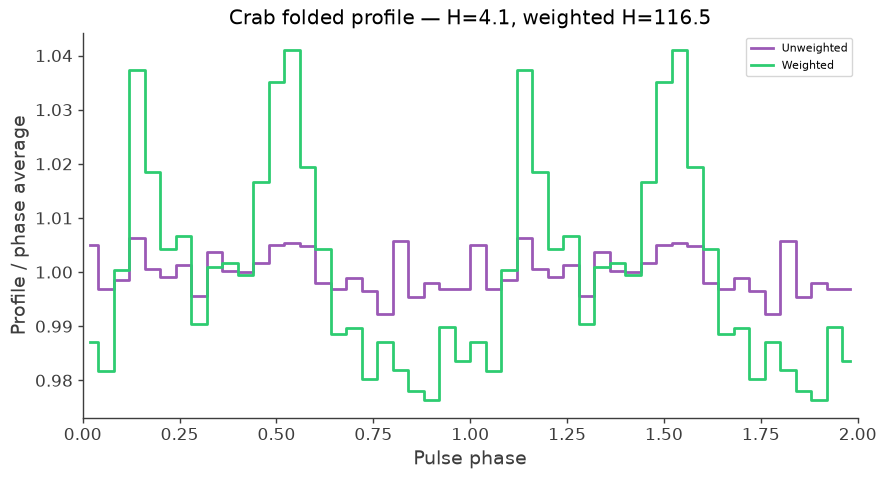

In [34]:
phase2 = np.concatenate([
    phase_centers,
    phase_centers + 1
])

unw2 = np.tile(profile_unw_norm, 2)
w2   = np.tile(profile_w_norm, 2)

unwerr2 = np.tile(err_unw_norm, 2)
werr2   = np.tile(err_w_norm, 2)

plt.figure(figsize=(10, 5))

plt.step(
    phase2,
    unw2,
    where="mid",
    label="Unweighted"
)

plt.step(
    phase2,
    w2,
    where="mid",
    label="Weighted"
)

plt.xlabel("Pulse phase")
plt.ylabel("Profile / phase average")
plt.xlim(0, 2)
plt.legend()

plt.title(
    f"Crab folded profile — "
    f"H={H_unw:.1f}, weighted H={H_w:.1f}"
)

plt.show()

# Experiment with cuts based on weights

This final experiment asks how much timing information is retained after progressively removing low-weight events. It compares a hard-cut unweighted H-test with the weighted H-test using the surviving events' original weights.

PS: Performing a hard-cut on weights, then calculating unweighted H-test is not something you would do, after all, you already have the weights - this is a simple test to check at which weight values does the background start becoming more dominant

In [35]:
# Test whether keeping only higher-probability source events changes the pulsation significance.
# Sample at a reasonable set of weight thresholds
# Use finer spacing at low weights, where most events lie,
# and linear spacing through the higher-weight tail

weight_cuts = np.unique(
    np.concatenate([
        [0.0],
        np.geomspace(1e-5, 0.1, 50),
        np.linspace(0.1, 0.8, 71)
    ])
)

H_unw_cut = np.full(len(weight_cuts), np.nan)
H_w_cut   = np.full(len(weight_cuts), np.nan)

m_unw_cut = np.full(len(weight_cuts), -1, dtype=int)
m_w_cut   = np.full(len(weight_cuts), -1, dtype=int)

n_keep   = np.zeros(len(weight_cuts), dtype=int)
sum_w    = np.zeros(len(weight_cuts))
sum_w2   = np.zeros(len(weight_cuts))

# Don't interpret H values based on only a handful of photons
min_events = 100

for j, wcut in enumerate(weight_cuts):

    mask = weights >= wcut

    ph = phase[mask]
    ww = weights[mask]

    n_keep[j] = mask.sum()
    sum_w[j]  = ww.sum()
    sum_w2[j] = np.sum(ww**2)

    if n_keep[j] < min_events:
        continue

    # Hard-cut analysis: surviving photons all get weight 1
    Hu, mu, _ = h_test(ph)

    # Weighted analysis: retain their original probability weights
    Hw, mw, _ = h_test(ph, weights=ww)

    H_unw_cut[j] = Hu
    H_w_cut[j]   = Hw

    m_unw_cut[j] = mu
    m_w_cut[j]   = mw

In [36]:
iu = np.nanargmax(H_unw_cut)
iw = np.nanargmax(H_w_cut)

print("BEST HARD-CUT / UNWEIGHTED RESULT")
print("---------------------------------")
print(f"Weight cut       : {weight_cuts[iu]:.6f}")
print(f"Events retained  : {n_keep[iu]:,}")
print(f"Fraction retained: {n_keep[iu]/len(weights):.4%}")
print(f"H                : {H_unw_cut[iu]:.3f}")
print(f"Best harmonic    : {m_unw_cut[iu]}")

print()

print("BEST WEIGHTED RESULT")
print("--------------------")
print(f"Weight cut       : {weight_cuts[iw]:.6f}")
print(f"Events retained  : {n_keep[iw]:,}")
print(f"Fraction retained: {n_keep[iw]/len(weights):.4%}")
print(f"H_w              : {H_w_cut[iw]:.3f}")
print(f"Best harmonic    : {m_w_cut[iw]}")

BEST HARD-CUT / UNWEIGHTED RESULT
---------------------------------
Weight cut       : 0.140000
Events retained  : 64,483
Fraction retained: 3.4455%
H                : 86.182
Best harmonic    : 6

BEST WEIGHTED RESULT
--------------------
Weight cut       : 0.015264
Events retained  : 667,024
Fraction retained: 35.6411%
H_w              : 118.858
Best harmonic    : 6


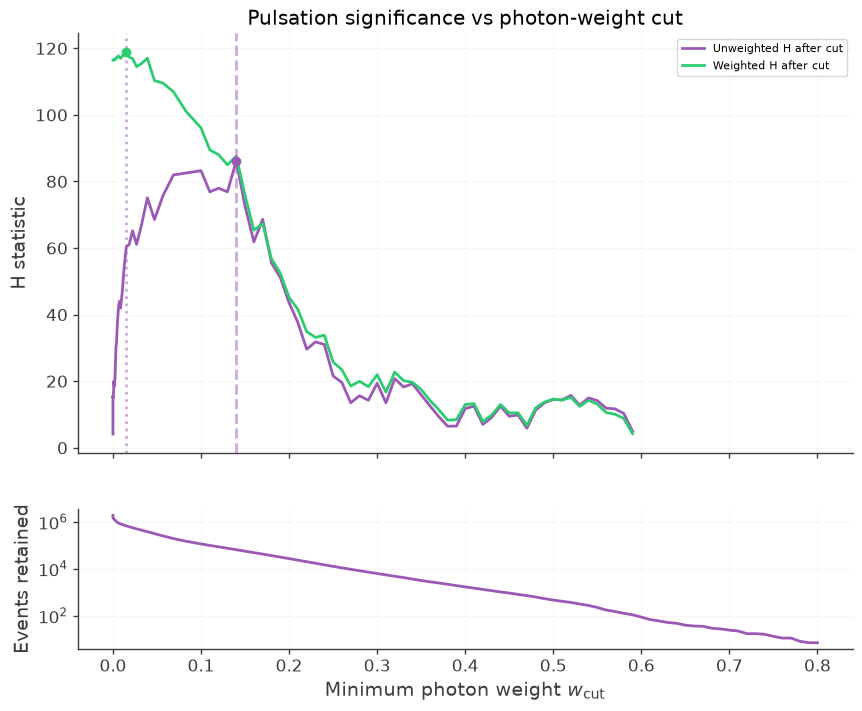

In [37]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]}
)

# ---------------------------------------------------------
# H statistic
# ---------------------------------------------------------

ax[0].plot(
    weight_cuts,
    H_unw_cut,
    label="Unweighted H after cut"
)

ax[0].plot(
    weight_cuts,
    H_w_cut,
    label="Weighted H after cut"
)

ax[0].axvline(
    weight_cuts[iu],
    ls="--",
    alpha=0.5
)

ax[0].axvline(
    weight_cuts[iw],
    ls=":",
    alpha=0.5
)

ax[0].scatter(
    weight_cuts[iu],
    H_unw_cut[iu],
    zorder=5
)

ax[0].scatter(
    weight_cuts[iw],
    H_w_cut[iw],
    zorder=5
)

ax[0].set_ylabel("H statistic")
ax[0].set_title("Pulsation significance vs photon-weight cut")
ax[0].legend()
ax[0].grid(alpha=0.2)


# ---------------------------------------------------------
# Number of retained photons
# ---------------------------------------------------------

ax[1].plot(
    weight_cuts,
    n_keep
)

ax[1].set_yscale("log")
ax[1].set_xlabel(r"Minimum photon weight $w_{\rm cut}$")
ax[1].set_ylabel("Events retained")
ax[1].grid(alpha=0.2)

plt.show()

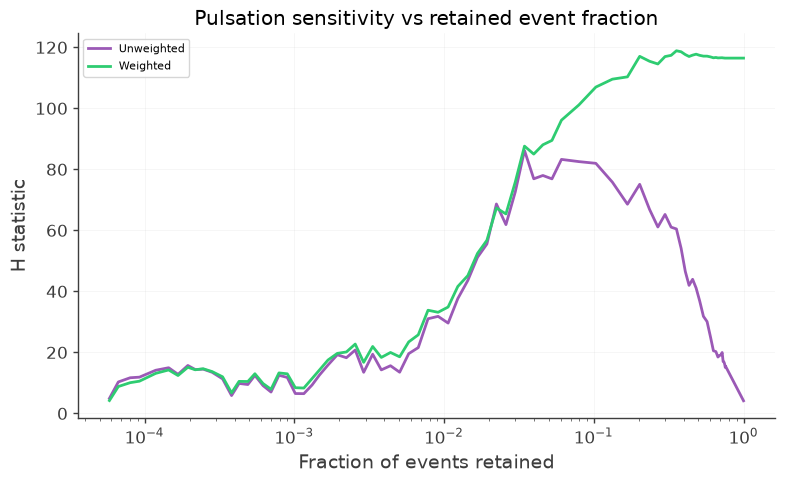

In [38]:
fraction_keep = n_keep / len(weights)

plt.figure(figsize=(9, 5))

plt.plot(
    fraction_keep,
    H_unw_cut,
    label="Unweighted"
)

plt.plot(
    fraction_keep,
    H_w_cut,
    label="Weighted"
)

plt.xscale("log")
plt.xlabel("Fraction of events retained")
plt.ylabel("H statistic")
plt.title("Pulsation sensitivity vs retained event fraction")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

# Few ideas for near-future work

- **Test things utilizing Israel's response.** Compared to the NN response, check for speed gain and pulsation signifigance performance (you should find that the speed gain is considerable and, even for the Crab, difference in pulsation significance is negligeable)
- **Test for fainter pulsars.** This may certainly require utilizing Israel's response, and likely running things on a cluster rather than locally
- **Beyond constant weights.** Start thinking of the methods developed in Bruel 2019 A&A, 622A, 108B to deal with cases of very faint pulsar detections